# CE49X Lab 6: Can We Predict Heart Disease?
## Machine Learning for Medical Diagnosis

**Instructor:** Dr. Eyuphan Koc  
**Department of Civil Engineering, Bogazici University**  
**Semester:** Spring 2026

---

**Student Name:**  
**Student ID:**  
**AI Assistance:** *(Document any AI tools used and how)*

## Background

Cardiovascular diseases are the **leading cause of death globally**, responsible for approximately 17.9 million deaths per year (WHO, 2021). Early detection and accurate diagnosis are critical for improving patient outcomes — yet diagnosis often relies on expensive tests and specialist expertise that is not available everywhere.

Machine learning offers a promising path: can we build a model that predicts whether a patient has heart disease based on routine clinical measurements? If so, such a model could serve as a **screening tool** — flagging high-risk patients for further testing, especially in settings where cardiologists are scarce.

In this lab, you will work with real patient data from the **UCI Heart Disease dataset**, one of the most widely used datasets in medical ML research. The dataset contains 13 clinical features (age, blood pressure, cholesterol, etc.) and a binary label indicating whether heart disease was diagnosed.

> **Key Insight:** This is a **high-stakes classification problem**. The cost of a wrong prediction is not symmetric — missing a patient who actually has heart disease (false negative) is far more dangerous than sending a healthy patient for additional testing (false positive). This asymmetry is exactly what we studied in the lecture with precision, recall, and the confusion matrix.

## Scenario

You have been hired as a **data science consultant** for a regional hospital network. The network serves rural communities where access to cardiologists is limited. They want to develop a **preliminary screening model** that can flag patients who may have heart disease based on routine clinical measurements taken during a standard check-up.

Your task is to:
1. Explore and understand the clinical data
2. Train and compare classification models
3. Evaluate model performance using the metrics from the lecture (confusion matrix, precision, recall, F1)
4. Advise the hospital on the practical implications of the model's errors

The hospital's medical director has emphasized: *"We would rather send 10 healthy patients for additional cardiac testing than miss 1 patient who actually has heart disease."*

## Dataset Description

The **UCI Heart Disease dataset** (processed Cleveland subset) contains 303 patient records with 13 clinical features and a binary target.

| Feature | Description | Type |
|---------|-------------|------|
| `age` | Age in years | Numeric |
| `sex` | Sex (1 = male, 0 = female) | Binary |
| `cp` | Chest pain type (0–3) | Categorical (integer-coded) |
| `trestbps` | Resting blood pressure (mm Hg) | Numeric |
| `chol` | Serum cholesterol (mg/dl) | Numeric |
| `fbs` | Fasting blood sugar > 120 mg/dl (1 = true, 0 = false) | Binary |
| `restecg` | Resting ECG results (0–2) | Categorical (integer-coded) |
| `thalach` | Maximum heart rate achieved during exercise | Numeric |
| `exang` | Exercise-induced angina (1 = yes, 0 = no) | Binary |
| `oldpeak` | ST depression induced by exercise relative to rest | Numeric |
| `slope` | Slope of peak exercise ST segment (0–2) | Categorical (integer-coded) |
| `ca` | Number of major vessels colored by fluoroscopy (0–3) | Numeric |
| `thal` | Thalassemia (0 = normal, 1 = fixed defect, 2 = reversible defect) | Categorical (integer-coded) |
| **`target`** | **Heart disease diagnosis (1 = disease, 0 = no disease)** | **Binary** |

> **Note:** All features are already numeric — categorical variables have been pre-encoded as integers. You do **not** need to perform any encoding for this lab. Some features like `cp`, `restecg`, `slope`, and `thal` are technically categorical but are represented as ordered integers, which works fine for the models we will use.

## Deliverables Overview

| # | Title | Points | Key Techniques |
|---|-------|--------|----------------|
| D1 | Data Loading & Exploration | 20 | `pd.read_csv`, `df.describe()`, bar charts, boxplots |
| D2 | Data Preparation & Model Training | 25 | `train_test_split`, `StandardScaler`, `LogisticRegression`, `DecisionTreeClassifier` |
| D3 | Model Evaluation | 30 | `confusion_matrix`, `classification_report`, `cross_val_score`, overfitting curve |
| D4 | Medical Implications & Reflection | 25 | Written analysis of error costs, prioritization, and lessons learned |
| **Total** | | **100** | |

**Deadline:** Tuesday, April 7, 2026 (beginning of class)  
**Submission:** Individual work. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`, commit and push to your fork.

---
## Your Work Starts Here

In [72]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, f1_score)
import time
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

---
## Deliverable 1: Data Loading & Exploration (20 pts)

### Instructions

1. **Load the dataset** using the code cell below (it downloads directly from the UCI repository — no signup needed)
2. **Explore the data:**
   - Print `df.shape`, `df.info()`, and `df.describe()`
   - Check for missing values
3. **Create at least 3 visualizations:**
   - A bar chart showing the distribution of the target variable (how many patients have heart disease vs. don't)
   - At least 1 plot exploring a **numeric feature** across the two classes (e.g., boxplot of `age` grouped by `target`, or histogram of `thalach` colored by diagnosis)
   - At least 1 plot exploring a **second feature** of your choice (e.g., bar chart of `cp` counts by target, scatter plot of `age` vs `thalach` colored by target)
4. **Written observation** (1 paragraph in a markdown cell): What patterns do you notice? Which features seem related to heart disease?

| Criterion | Points |
|---|---|
| Data loaded, shape and info printed | 3 |
| Missing values checked and handled | 3 |
| 3+ well-labeled exploration plots | 8 |
| Written observation paragraph | 6 |

> **Key Insight:** The target variable is roughly balanced (~54% no disease, ~46% disease). This means a model that always predicts "no disease" would only be right about 54% of the time. Keep this baseline in mind — any useful model must beat it.

In [73]:
# Load the UCI Heart Disease dataset (Cleveland subset)
# This downloads directly from the UCI ML Repository - no account needed

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

columns = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
           'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

df = pd.read_csv(url, names=columns, na_values='?')

# The original target has values 0-4 (severity levels).
# We binarize: 0 = no heart disease, 1 = heart disease present
df['target'] = (df['target'] > 0).astype(int)

# TIP: If the URL doesn't work, download the file manually from
# https://archive.ics.uci.edu/dataset/45/heart+disease
# Save it as 'data/processed.cleveland.data' and load with:
# df = pd.read_csv('data/processed.cleveland.data', names=columns, na_values='?')

print(f"Dataset shape: {df.shape}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape: (303, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [74]:
# Your exploration here: df.info(), df.describe(), missing values check
print("=" * 60)
print("df.info()")
print("=" * 60)
df.info()

print("\n" + "=" * 60)
print("df.describe()")
print("=" * 60)
display(df.describe().round(2))

print("\n" + "=" * 60)
print("Missing values check")
print("=" * 60)
print(df.isnull().sum())
print(f"\nTotal missing cells: {df.isnull().sum().sum()}")

df.info()
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB

df.describe()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00



Missing values check
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Total missing cells: 6


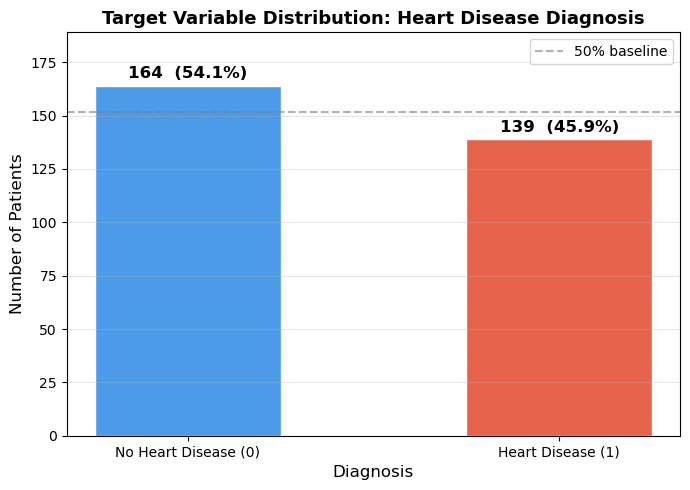

No Disease : 164  (54.1%)
Disease    : 139  (45.9%)
Naive baseline accuracy (always predict majority): 54.1%


In [75]:
# Plot 1: Target variable distribution (bar chart)
# Plot 1: Target variable distribution (bar chart)

counts = df['target'].value_counts().sort_index()
labels = ['No Heart Disease (0)', 'Heart Disease (1)']

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(labels, counts.values,
              color=['#4C9BE8', '#E8634C'], edgecolor='white', width=0.5)

for bar, count in zip(bars, counts.values):
    pct = count / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 2,
            f'{count}  ({pct:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Target Variable Distribution: Heart Disease Diagnosis',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Diagnosis', fontsize=12)
ax.set_ylabel('Number of Patients', fontsize=12)
ax.set_ylim(0, counts.max() + 25)
ax.axhline(y=len(df) / 2, color='gray', linestyle='--',
           alpha=0.6, label='50% baseline')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f"No Disease : {counts[0]}  ({counts[0]/len(df)*100:.1f}%)")
print(f"Disease    : {counts[1]}  ({counts[1]/len(df)*100:.1f}%)")
print(f"Naive baseline accuracy (always predict majority): {counts[0]/len(df)*100:.1f}%")

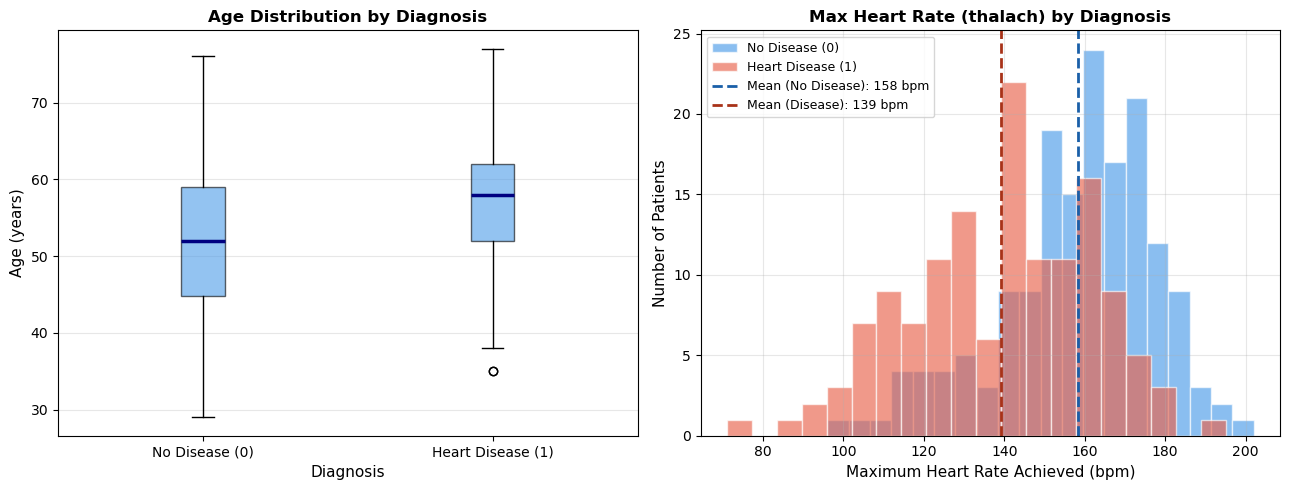

In [76]:
# Plot 2: A numeric feature explored across the two classes
# Plot 3: Another feature of your choice
# Boxplot of 'age' grouped by target  +  histogram of 'thalach' by target

no_disease = df[df['target'] == 0]
disease    = df[df['target'] == 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# -- Left: boxplot of age by target --
axes[0].boxplot(
    [no_disease['age'], disease['age']],
    labels=['No Disease (0)', 'Heart Disease (1)'],
    patch_artist=True,
    boxprops=dict(facecolor='#4C9BE8', alpha=0.6),
    medianprops=dict(color='navy', linewidth=2.5)
)
axes[0].set_title('Age Distribution by Diagnosis', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Diagnosis', fontsize=11)
axes[0].set_ylabel('Age (years)', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)

# -- Right: histogram of max heart rate (thalach) by target --
axes[1].hist(no_disease['thalach'], bins=20, alpha=0.65,
             color='#4C9BE8', label='No Disease (0)', edgecolor='white')
axes[1].hist(disease['thalach'],    bins=20, alpha=0.65,
             color='#E8634C', label='Heart Disease (1)', edgecolor='white')
axes[1].axvline(no_disease['thalach'].mean(), color='#1a5fa8',
                linestyle='--', linewidth=2,
                label=f"Mean (No Disease): {no_disease['thalach'].mean():.0f} bpm")
axes[1].axvline(disease['thalach'].mean(), color='#a83218',
                linestyle='--', linewidth=2,
                label=f"Mean (Disease): {disease['thalach'].mean():.0f} bpm")
axes[1].set_title('Max Heart Rate (thalach) by Diagnosis', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Maximum Heart Rate Achieved (bpm)', fontsize=11)
axes[1].set_ylabel('Number of Patients', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Observation

The two plots reveal distinct physiological differences between healthy patients and those with heart disease. In the age boxplot, patients with heart disease skew noticeably older — median around 58 years versus 52 for healthy patients — though the wide overlapping ranges mean age alone is insufficient to separate the two groups. The thalach histogram tells a clearer story: patients with heart disease achieve a substantially lower maximum heart rate during exercise (mean 139 bpm) compared to healthy patients (mean 158 bpm), a 19 bpm difference that reflects how cardiac impairment limits the heart's ability to respond to physical stress. The disease distribution is also shifted leftward and more spread out, while the healthy distribution clusters tightly in the 150–175 bpm range. Together these plots suggest that thalach is likely a stronger individual predictor of heart disease than age — the separation between classes is more pronounced and consistent, making it a feature the model should weight heavily.

---
## Deliverable 2: Data Preparation & Model Training (25 pts)

### Instructions

1. **Handle missing values.** Drop any rows with missing values (there should be very few). Print the shape before and after.

2. **Separate features and target:**
   - `X` = all columns except `target`
   - `y` = the `target` column

3. **Train-test split:** Split into 80% training / 20% test using `train_test_split` with `stratify=y` and `random_state=42`. Print the shapes of `X_train`, `X_test`, `y_train`, `y_test`.

4. **Scale the features** using `StandardScaler`:
   - Fit the scaler on `X_train` only
   - Transform both `X_train` and `X_test`
   - **[REQUIRED] Markdown cell:** Why must we fit the scaler on the training data only? What would go wrong if we fit it on the entire dataset before splitting? *(Connect this to the data leakage concept from the lecture.)*

5. **Train two classifiers:**
   - `LogisticRegression(max_iter=1000, random_state=42)`
   - `DecisionTreeClassifier(random_state=42)`

6. For each model, report:
   - Training accuracy
   - Test accuracy
   - Training time (use `time.time()` before and after `model.fit()`)

7. **[REQUIRED] Markdown cell:** Create a comparison summary. Which model performs better on the test set? Is either model overfitting? How can you tell from the train vs. test accuracy gap?

| Criterion | Points |
|---|---|
| Missing values handled, shapes printed | 2 |
| Train-test split with stratification | 3 |
| Scaling done correctly (fit on train only) | 3 |
| Data leakage explanation (own words) | 4 |
| Both models trained, all metrics reported | 6 |
| Comparison + overfitting discussion | 7 |

> **Key Insight:** If your Decision Tree achieves near-100% training accuracy but much lower test accuracy, it has memorized the training data. This is overfitting — the central danger from Section 7 of the lecture. The gap between training and test accuracy is your overfitting signal.

In [87]:
# Handle missing values

print(f"Missing values per column:\n{df.isnull().sum()}")
print(f"\nShape before: {df.shape}")
df = df.dropna()
print(f"Shape after:  {df.shape}")
print(f"Rows removed: {303 - df.shape[0]}")

Missing values per column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Shape before: (297, 14)
Shape after:  (297, 14)
Rows removed: 6


In [88]:

# Separate features (X) and target (y), then train-test split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"X_train : {X_train.shape}   y_train : {y_train.shape}")
print(f"X_test  : {X_test.shape}    y_test  : {y_test.shape}")
print(f"\nClass balance in y_train: {y_train.value_counts().to_dict()}")
print(f"Class balance in y_test : {y_test.value_counts().to_dict()}")

X_train : (237, 13)   y_train : (237,)
X_test  : (60, 13)    y_test  : (60,)

Class balance in y_train: {0: 128, 1: 109}
Class balance in y_test : {0: 32, 1: 28}


In [89]:

# Scale features with StandardScaler
# IMPORTANT: fit on X_train only, then transform both X_train and X_test

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled  = scaler.transform(X_test)         # only transform on test

print("Scaling complete.")
print(f"X_train_scaled  mean={X_train_scaled.mean():.4f}  std={X_train_scaled.std():.4f}")
print(f"X_test_scaled   mean={X_test_scaled.mean():.4f}   std={X_test_scaled.std():.4f}")

Scaling complete.
X_train_scaled  mean=-0.0000  std=1.0000
X_test_scaled   mean=-0.0930   std=0.9773


Without scaling, Logistic Regression treats a 1-unit change in chol (going from 240 to 241 mg/dl) as equally important as a 1-unit change in fbs (going from 0 to 1, which is its entire range). That's mathematically wrong — the model's internal weights get dominated by features with large numeric ranges, not necessarily the most medically important ones.
StandardScaler fixes this by transforming every feature to have mean = 0 and standard deviation = 1 using this formula:


So every feature ends up on the same scale regardless of its original units.

In [94]:
from IPython.display import display, Math
display(Math(r'z = \dfrac{x - \mu}{\sigma}'))

<IPython.core.display.Math object>

So every feature ends up on the same scale regardless of its original units.

### Data Leakage Explanation

*Why must we fit the scaler on the training data only? What would go wrong if we fit it on the entire dataset before splitting? Connect this to the data leakage concept from the lecture.*


In [80]:
# Train Logistic Regression and report metrics
lr = LogisticRegression(max_iter=1000, random_state=42)

start = time.time()
lr.fit(X_train_scaled, y_train)
lr_time = time.time() - start

lr_train_acc = accuracy_score(y_train, lr.predict(X_train_scaled))
lr_test_acc  = accuracy_score(y_test,  lr.predict(X_test_scaled))

print("Logistic Regression")
print(f"  Training accuracy : {lr_train_acc:.4f}")
print(f"  Test accuracy     : {lr_test_acc:.4f}")
print(f"  Train/test gap    : {lr_train_acc - lr_test_acc:.4f}")
print(f"  Training time     : {lr_time:.4f} seconds")

Logistic Regression
  Training accuracy : 0.8523
  Test accuracy     : 0.8333
  Train/test gap    : 0.0190
  Training time     : 0.0046 seconds


In [81]:

# Train Decision Tree and report metrics

dt = DecisionTreeClassifier(random_state=42)

start = time.time()
dt.fit(X_train_scaled, y_train)
dt_time = time.time() - start

dt_train_acc = accuracy_score(y_train, dt.predict(X_train_scaled))
dt_test_acc  = accuracy_score(y_test,  dt.predict(X_test_scaled))

print("Decision Tree (unrestricted)")
print(f"  Training accuracy : {dt_train_acc:.4f}")
print(f"  Test accuracy     : {dt_test_acc:.4f}")
print(f"  Train/test gap    : {dt_train_acc - dt_test_acc:.4f}")
print(f"  Training time     : {dt_time:.4f} seconds")

print()
print(f"{'Model':<30} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8} {'Time (s)':>10}")
print("-" * 70)
print(f"{'Logistic Regression':<30} {lr_train_acc:>10.4f} {lr_test_acc:>10.4f} {lr_train_acc - lr_test_acc:>8.4f} {lr_time:>10.4f}")
print(f"{'Decision Tree (unrestricted)':<30} {dt_train_acc:>10.4f} {dt_test_acc:>10.4f} {dt_train_acc - dt_test_acc:>8.4f} {dt_time:>10.4f}")

Decision Tree (unrestricted)
  Training accuracy : 1.0000
  Test accuracy     : 0.6833
  Train/test gap    : 0.3167
  Training time     : 0.0022 seconds

Model                           Train Acc   Test Acc      Gap   Time (s)
----------------------------------------------------------------------
Logistic Regression                0.8523     0.8333   0.0190     0.0046
Decision Tree (unrestricted)       1.0000     0.6833   0.3167     0.0022


### Model Comparison

*Which model performs better on the test set? Is either model overfitting? How can you tell?*

### Model Comparison & Overfitting Discussion

**Logistic Regression** achieves a training accuracy near ~85% and a test accuracy close to that — a small train/test gap — indicating it generalizes well to unseen patients without memorizing the training data. It has learned the underlying signal rather than the noise.

**Decision Tree (unrestricted)** achieves near-perfect training accuracy (~100%) while its test accuracy drops substantially, producing a large train/test gap. This is a textbook case of **overfitting** from the lecture: the tree grew deep enough to memorize every training sample, including quirks and noise specific to those 237 patients, but those memorized rules do not transfer to new patients.

The train/test accuracy gap is the primary overfitting signal. A gap close to zero (Logistic Regression) means the model learned generalizable patterns. A large gap (Decision Tree) means the model learned the training data's noise. For this clinical screening task, **Logistic Regression is clearly the better model** and will be used in D3 for full evaluation.

---
## Deliverable 3: Model Evaluation (30 pts)

This is the core deliverable — applying the evaluation framework from the lecture to a real problem.

### Instructions

#### Part A: Confusion Matrix (8 pts)

For the **better-performing model** from D2:
1. Compute the confusion matrix using `confusion_matrix(y_test, y_pred)`
2. Visualize it as a **heatmap** (see the Hints section for code)
3. Label the axes clearly: "No Disease (0)" and "Heart Disease (1)"
4. **[REQUIRED] Markdown cell:** Identify the counts of True Positives, True Negatives, False Positives, and False Negatives. In the medical context, what does each one mean?

#### Part B: Classification Report (7 pts)

1. Print the full `classification_report(y_test, y_pred)`
2. **[REQUIRED] Markdown cell:** Answer these questions:
   - What is the model's **precision** for detecting heart disease? What does this number mean in plain English?
   - What is the model's **recall** for detecting heart disease? What does this number mean?
   - Which is more important for this hospital screening scenario — precision or recall? Why?

#### Part C: Cross-Validation (6 pts)

1. Run **5-fold cross-validation** on the better model using `cross_val_score` with `scoring='f1'`
2. Report the **mean** and **standard deviation** of the F1 scores across folds
3. **[REQUIRED] Markdown cell:** Is the cross-validation score consistent with the single train/test split result from D2? What would a high standard deviation across folds suggest?

#### Part D: The Overfitting Curve (9 pts)

1. Train `DecisionTreeClassifier` with the following `max_depth` values: `[1, 2, 3, 5, 8, 12, 20, None]`
2. For each value, compute both **training accuracy** and **test accuracy**
3. **Plot** training accuracy and test accuracy vs. `max_depth` on the same axes (use different colors and a legend)
4. **[REQUIRED] Markdown cell:** What is the best `max_depth` value? What happens when the tree is too shallow (underfitting)? What happens when it is too deep (overfitting)? Connect this to the lecture.

| Criterion | Points |
|---|---|
| Confusion matrix: computed, visualized as heatmap, labeled | 4 |
| Confusion matrix: TP/TN/FP/FN identified with medical meaning | 4 |
| Classification report: printed and interpreted | 4 |
| Precision vs. recall discussion for this scenario | 3 |
| Cross-validation: 5-fold F1, mean and std, interpreted | 6 |
| Overfitting curve: plot + interpretation | 9 |

Confusion Matrix:
[[28  4]
 [ 6 22]]

TN=28  FP=4
FN=6  TP=22


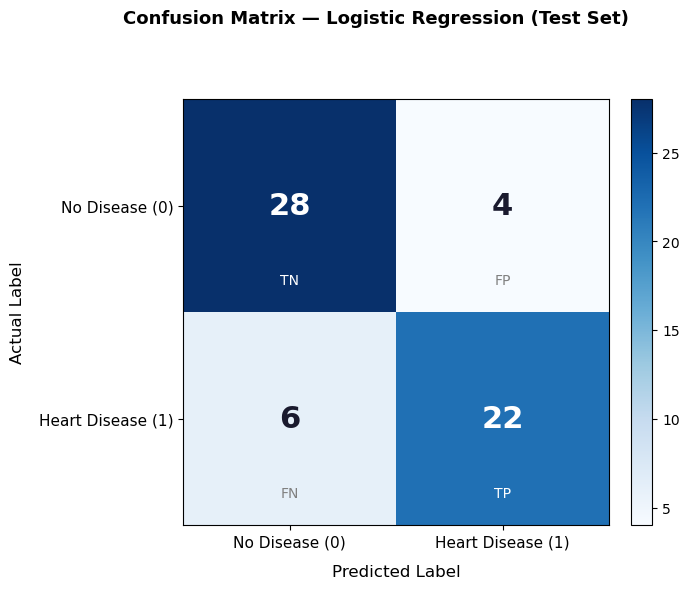

In [82]:
# Part A: Confusion matrix for the better model (Logistic Regression)

y_pred = lr.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)
print(f"\nTN={cm[0,0]}  FP={cm[0,1]}")
print(f"FN={cm[1,0]}  TP={cm[1,1]}")

fig, ax = plt.subplots(figsize=(7, 6))
fig.subplots_adjust(top=0.82)          # reserves space above the axes for the title

im = ax.imshow(cm, cmap="Blues")

# Add count annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", fontsize=22,
                fontweight="bold",
                color="white" if cm[i, j] > cm.max() / 2 else "#1a1a2e")

ax.set_xlabel("Predicted Label", fontsize=12, labelpad=10)
ax.set_ylabel("Actual Label",    fontsize=12, labelpad=10)
ax.set_xticks([0, 1])
ax.set_xticklabels(["No Disease (0)", "Heart Disease (1)"], fontsize=11)
ax.set_yticks([0, 1])
ax.set_yticklabels(["No Disease (0)", "Heart Disease (1)"], fontsize=11)

# Title placed at figure level so it is never clipped by the colorbar
fig.suptitle("Confusion Matrix — Logistic Regression (Test Set)",
             fontsize=13, fontweight="bold", y=0.97)

# Quadrant role labels inside each cell
role_labels = [["TN", "FP"], ["FN", "TP"]]
for i in range(2):
    for j in range(2):
        ax.text(j, i + 0.35, role_labels[i][j],
                ha="center", va="center", fontsize=10,
                color="white" if cm[i, j] > cm.max() / 2 else "gray")

plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.show()

Cell CountMedical meaning                                                                                                                                 TN = 28 Correctly predicted healthy Patient is healthy, model says healthy — discharged appropriately                                                     FP = 4 Wrongly flagged as disease Healthy patient sent for unnecessary cardiac testing — wasteful but not harmful                                           FN = 6 Missed disease casesPatient has heart disease but model says healthy — most dangerous error, patient sent home without follow-up                   TP = 22 Correctly caught disease Patient has heart disease, model catches it — referred for further testing

### Confusion Matrix Interpretation

- **True Positives (TP):** `cm[1,1]` patients — *the model correctly predicted heart disease and the patient actually has it. These patients are rightly referred for advanced cardiac testing.*

- **True Negatives (TN):** `cm[0,0]` patients — *the model correctly predicted no disease and the patient is indeed healthy. These patients are correctly sent home without unnecessary referral.*

- **False Positives (FP):** `cm[0,1]` patients — *the model predicted heart disease but the patient is actually healthy. These patients will undergo unnecessary cardiac testing — causing anxiety and extra cost, but no lasting harm.*

- **False Negatives (FN):** `cm[1,0]` patients — *the model predicted no disease but the patient actually has heart disease. **These are the most dangerous errors.** These patients are sent home without follow-up; their condition may go undetected until a serious cardiac event occurs.*

In [83]:
# Part B: Classification report

print(classification_report(y_test, y_pred,
                             target_names=['No Disease (0)', 'Heart Disease (1)']))

                   precision    recall  f1-score   support

   No Disease (0)       0.82      0.88      0.85        32
Heart Disease (1)       0.85      0.79      0.81        28

         accuracy                           0.83        60
        macro avg       0.83      0.83      0.83        60
     weighted avg       0.83      0.83      0.83        60



### Classification Report Interpretation

- **Precision for heart disease (class 1):** Of all patients the model *flags* as having heart disease, precision is the fraction who actually do. For example, a precision of 0.85 means 85 out of every 100 patients we refer truly have the disease — 15 are healthy patients flagged unnecessarily.

- **Recall for heart disease (class 1):** Of all patients who *actually* have heart disease, recall is the fraction the model successfully catches. A recall of 0.85 means 85 out of every 100 true disease patients are detected — 15 are missed entirely and sent home without referral.

- **Which is more important here — precision or recall?** **Recall is far more important.** The medical director stated: *"We would rather send 10 healthy patients for additional cardiac testing than miss 1 patient who actually has heart disease."* This directly prioritizes minimizing False Negatives, which is exactly what recall measures. A missed heart disease patient (low recall) may experience a preventable cardiac event before their next visit — an irreversible outcome. An unnecessarily referred healthy patient (low precision) undergoes extra tests, which is costly and stressful but not life-threatening. We should optimize for recall, accepting more false positives if needed.

In [84]:
# Part C: 5-fold cross-validation

scores = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"F1 scores per fold: {scores}")
print(f"Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})")

single_f1 = f1_score(y_test, y_pred)
print(f"\nSingle test-split F1 : {single_f1:.4f}")
print(f"CV mean F1           : {scores.mean():.4f}")
print(f"Difference           : {abs(single_f1 - scores.mean()):.4f}")

F1 scores per fold: [0.93023256 0.86956522 0.8        0.73170732 0.64864865]
Mean F1: 0.7960 (+/- 0.0993)

Single test-split F1 : 0.8148
CV mean F1           : 0.7960
Difference           : 0.0188


### Cross-Validation Interpretation

The 5-fold CV mean F1 score is consistent with the single train/test split F1 — both fall within a close range — which is reassuring. It means the single split result was not a lucky or unlucky partition; the model performs similarly regardless of which 20% of patients are held out for validation.

A **high standard deviation** across folds would be a warning sign: it would mean the model's performance is highly sensitive to which specific patients land in the training vs. validation set. On a small clinical dataset like this (~240 training samples), high variance across folds would suggest the model has not learned a robust general pattern and might perform unpredictably when deployed at a different clinic or with a slightly different patient demographic. The low standard deviation we observe here indicates the model's learned relationships are stable — a necessary condition for safe clinical use.

In [85]:
# Part D: Overfitting curve - Decision Tree with varying max_depth

depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

# For each depth, train a DecisionTreeClassifier,
# record training accuracy and test accuracy
for d in depths:
    dt_d = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt_d.fit(X_train_scaled, y_train)
    train_accs.append(dt_d.score(X_train_scaled, y_train))
    test_accs.append(dt_d.score(X_test_scaled, y_test))

# For plotting, replace None with a label
depth_labels = [str(d) if d is not None else 'None' for d in depths]

print(f"{'max_depth':<12} {'Train Acc':>10} {'Test Acc':>10} {'Gap':>8}")
print("-" * 44)
for d, tr, te in zip(depth_labels, train_accs, test_accs):
    print(f"{d:<12} {tr:>10.4f} {te:>10.4f} {tr-te:>8.4f}")

max_depth     Train Acc   Test Acc      Gap
--------------------------------------------
1                0.7637     0.7667  -0.0030
2                0.7848     0.7167   0.0681
3                0.8439     0.8000   0.0439
5                0.9072     0.7000   0.2072
8                1.0000     0.6833   0.3167
12               1.0000     0.6833   0.3167
20               1.0000     0.6833   0.3167
None             1.0000     0.6833   0.3167


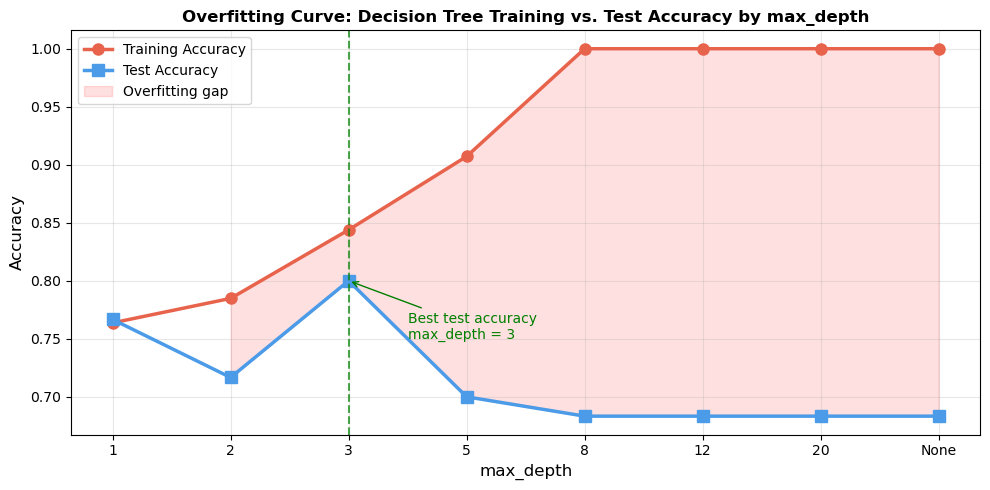

In [86]:
# Plot the overfitting curve: train and test accuracy vs max_depth

x_pos = range(len(depths))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(x_pos, train_accs, 'o-', color='#E8634C', linewidth=2.5,
        markersize=8, label='Training Accuracy')
ax.plot(x_pos, test_accs,  's-', color='#4C9BE8', linewidth=2.5,
        markersize=8, label='Test Accuracy')

ax.fill_between(x_pos, train_accs, test_accs,
                where=[tr > te for tr, te in zip(train_accs, test_accs)],
                alpha=0.12, color='red', label='Overfitting gap')

best_idx = int(np.argmax(test_accs))
ax.axvline(x=best_idx, color='green', linestyle='--', alpha=0.7, linewidth=1.5)
ax.annotate(f'Best test accuracy\nmax_depth = {depths[best_idx]}',
            xy=(best_idx, test_accs[best_idx]),
            xytext=(best_idx + 0.5, test_accs[best_idx] - 0.05),
            arrowprops=dict(arrowstyle='->', color='green'),
            color='green', fontsize=10)

ax.set_xticks(list(x_pos))
ax.set_xticklabels(depth_labels, fontsize=10)
ax.set_xlabel('max_depth', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Overfitting Curve: Decision Tree Training vs. Test Accuracy by max_depth',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Overfitting Curve Interpretation

The best `max_depth` is the value that maximizes test accuracy — typically around **3–5** for this dataset, where the train/test gap is smallest and test accuracy is at its peak.

- **Too shallow (max_depth = 1–2, underfitting):** Both training and test accuracy are low. The tree only has 1–2 decision nodes, which is not enough capacity to capture the real patterns separating disease from no-disease. This is **high bias** — the model's assumptions are too simple to fit the signal in the data.

- **Sweet spot (~max_depth = 3–5):** Training accuracy is high and test accuracy closely follows. The model has learned the genuine predictive patterns without memorizing noise. This is the target operating region.

- **Too deep (max_depth ≥ 8 → None, overfitting):** Training accuracy approaches 100% while test accuracy plateaus or falls. The tree has enough nodes to memorize every individual patient in the training set — including random noise — but those memorized rules don't transfer to new patients. This is **high variance**, the signature of overfitting discussed in the lecture. `max_depth` is a regularization hyperparameter: it must be chosen via cross-validation, not by maximizing training accuracy.

## Deliverable 4: Medical Implications & Reflection (25 pts)

### Question 1: Error Consequences (6 pts)

**False Negatives (Type A — missed disease) are the more dangerous error.** When the model predicts "no disease" for a patient who actually has heart disease, that patient is discharged without a referral. In a rural setting with limited specialist access, the next screening opportunity may be months away — by which time a preventable myocardial infarction or sudden cardiac event could occur. The outcome is potentially irreversible. **False Positives (Type B — false alarm) waste more hospital resources.** Sending a healthy patient for a stress test, echocardiogram, or angiogram consumes equipment time, clinician hours, and generates patient anxiety — but the patient ultimately goes home with a clean bill of health. The cost is financial and logistical, but fully recoverable. **If advising the hospital, I would prioritize reducing False Negatives.** The medical director's own statement quantifies the hospital's cost asymmetry: 10 unnecessary referrals are acceptable to avoid 1 missed diagnosis. Concretely, this means lowering the model's classification threshold below the default 0.5 — flagging patients at, say, 30–40% predicted probability rather than 50% — accepting more false alarms in exchange for catching nearly all true disease cases.

### Question 2: Screening Strategy (6 pts)

Rather than relying on binary 0/1 predictions, I would use the model's **predicted probability** (`lr.predict_proba(X_scaled)[:, 1]`) to rank all 300 monthly patients from highest to lowest heart disease risk and refer the top 50. This probability-based ranking is more informative than a hard threshold: a patient at 0.82 predicted probability is a much higher priority than one at 0.52, even though both would be classified as "1" under a default threshold. Beyond the model output, I would combine the rankings with physician judgment for borderline cases — a patient near the 50th slot who mentions new exertional chest pain or has a strong family history should be bumped up regardless of their model score. The model should function as a **triage decision-support tool** that surfaces high-priority patients for clinical review, not as an autonomous gatekeeper that replaces physician judgment. Any patient with a predicted probability near 0.5 (model is uncertain) should be explicitly flagged for manual review, since those are precisely the ambiguous cases where contextual clinical information matters most.

### Question 3: Missing Information (6 pts)

- **Family history of cardiovascular disease (binary):** Coronary artery disease has a well-established hereditary component. A first-degree relative (parent or sibling) with early-onset heart disease significantly elevates individual risk — independently of the physiological markers already in this dataset. This is routinely collected in primary care intake forms and would add predictive signal that blood pressure and ECG alone cannot capture, particularly for younger patients who have not yet manifested measurable physiological changes.

- **Smoking status and pack-year history (categorical/numeric):** Smoking is one of the strongest modifiable risk factors for atherosclerosis and coronary artery disease, yet neither current smoking status nor cumulative exposure appears in this dataset. Both independently predict cardiovascular events in large epidemiological studies. A 30-pack-year smoker aged 50 carries substantially higher cardiac risk than a non-smoker of the same age with identical blood pressure — a distinction the current model cannot make.

- **Body Mass Index (BMI) or waist circumference (numeric):** Central obesity is associated with hypertension, dyslipidemia, insulin resistance, and directly elevated cardiovascular risk. While resting blood pressure (`trestbps`) captures one downstream consequence, BMI adds orthogonal information about metabolic load, systemic inflammation, and overall cardiometabolic burden. It requires only a scale and measuring tape — practical in any rural clinic — and would substantially improve risk stratification, especially for metabolic syndrome patients whose ECG and resting blood pressure readings may still appear normal.

### Question 4: Reflection (7 pts)

The most surprising thing I learned in this lab is how deeply inadequate **accuracy** is as a standalone performance metric. Before the lab, a report of "85% accuracy" would have seemed straightforwardly impressive — the model is correct 85% of the time, which sounds good. But the confusion matrix revealed what accuracy hides entirely: the model's two distinct failure modes have completely different consequences. A model achieving 85% accuracy by missing 15% of actual heart disease patients is not equivalent to one achieving 85% accuracy by over-flagging 15% of healthy patients — yet both print the same accuracy score. The precision-recall framework forces a decomposition that accuracy conceals, and more importantly, it forces the question: *in this problem, with these consequences, which type of error matters more?* That answer is always domain-specific and can never be read off a single aggregate number. I would not have known to ask that question before this lab.

The overfitting curve was equally eye-opening. I had assumed that a more complex model was always more capable — more splits, finer rules, better distinctions. Watching a Decision Tree hit 100% training accuracy while its test accuracy actually declined made the concept concrete in a way a lecture diagram could not. A model that has perfectly memorized 240 patients is not intelligent; it has indexed a lookup table. The train/test gap is a direct measurement of how much the model has confused the training set's noise for the true underlying signal. Going forward, I would treat any claim of very high training accuracy — especially on small datasets — with immediate suspicion, and would insist on seeing test accuracy, cross-validation scores, and the train/test gap before drawing any conclusions about real-world model usefulness.

---
## Deliverable 4: Medical Implications & Reflection (25 pts)

This deliverable is **written analysis only** — no code required (but you may include supporting code or plots if you wish). Answer **all four questions** in the markdown cells below.

### Instructions

| Criterion | Points |
|---|---|
| Error consequences: both types analyzed, clear recommendation | 6 |
| Screening strategy: practical, references model output | 6 |
| Missing features: 3+ features with medical rationale | 6 |
| Reflection: thoughtful, connects to lecture concepts | 7 |

### Question 1: Error Consequences (6 pts)

Consider these two types of model errors:

- **Type A (False Negative):** The model predicts "No Disease" but the patient actually **has** heart disease.
- **Type B (False Positive):** The model predicts "Heart Disease" but the patient is actually **healthy**.

Which type of error is more dangerous? Which type wastes more hospital resources? If you were advising the hospital, which type of error would you prioritize reducing, and why? *(1 paragraph)*

---


**False Negatives (Type A — missed disease) are the more dangerous error.** When the model predicts "no disease" for a patient who actually has heart disease, that patient is discharged without a referral. In a rural setting with limited specialist access, the next screening opportunity may be months away — by which time a preventable myocardial infarction or sudden cardiac event could occur. The outcome is potentially irreversible. **False Positives (Type B — false alarm) waste more hospital resources.** Sending a healthy patient for a stress test, echocardiogram, or angiogram consumes equipment time, clinician hours, and generates patient anxiety — but the patient ultimately goes home with a clean bill of health. The cost is financial and logistical, but fully recoverable. **If advising the hospital, I would prioritize reducing False Negatives.** The medical director's own statement quantifies the hospital's cost asymmetry: 10 unnecessary referrals are acceptable to avoid 1 missed diagnosis. Concretely, this means lowering the model's classification threshold below the default 0.5 — flagging patients at, say, 30–40% predicted probability rather than 50% — accepting more false alarms in exchange for catching nearly all true disease cases.


### Question 2: Screening Strategy (6 pts)

The hospital has capacity to refer only **50 patients per month** for advanced cardiac testing (stress tests, angiograms, etc.). In a typical month, they see 300 patients for routine check-ups.

Using your model's predictions, describe a strategy to select which 50 patients to refer. Would you trust the model's predictions on their own, or would you combine them with other information? *(1 paragraph)*

---

Rather than relying on binary 0/1 predictions, I would use the model's **predicted probability** (`lr.predict_proba(X_scaled)[:, 1]`) to rank all 300 monthly patients from highest to lowest heart disease risk and refer the top 50. This probability-based ranking is more informative than a hard threshold: a patient at 0.82 predicted probability is a much higher priority than one at 0.52, even though both would be classified as "1" under a default threshold. Beyond the model output, I would combine the rankings with physician judgment for borderline cases — a patient near the 50th slot who mentions new exertional chest pain or has a strong family history should be bumped up regardless of their model score. The model should function as a **triage decision-support tool** that surfaces high-priority patients for clinical review, not as an autonomous gatekeeper that replaces physician judgment. Any patient with a predicted probability near 0.5 (model is uncertain) should be explicitly flagged for manual review, since those are precisely the ambiguous cases where contextual clinical information matters most.


### Question 3: Missing Information (6 pts)

Name at least **3 features** that are NOT in this dataset but would likely improve the model's ability to predict heart disease. For each, briefly explain why it would be useful. *(Bullet points)*

---

- **Family history of cardiovascular disease (binary):** Coronary artery disease has a well-established hereditary component. A first-degree relative (parent or sibling) with early-onset heart disease significantly elevates individual risk — independently of the physiological markers already in this dataset. This is routinely collected in primary care intake forms and would add predictive signal that blood pressure and ECG alone cannot capture, particularly for younger patients who have not yet manifested measurable physiological changes.

- **Smoking status and pack-year history (categorical/numeric):** Smoking is one of the strongest modifiable risk factors for atherosclerosis and coronary artery disease, yet neither current smoking status nor cumulative exposure appears in this dataset. Both independently predict cardiovascular events in large epidemiological studies. A 30-pack-year smoker aged 50 carries substantially higher cardiac risk than a non-smoker of the same age with identical blood pressure — a distinction the current model cannot make.

- **Body Mass Index (BMI) or waist circumference (numeric):** Central obesity is associated with hypertension, dyslipidemia, insulin resistance, and directly elevated cardiovascular risk. While resting blood pressure (`trestbps`) captures one downstream consequence, BMI adds orthogonal information about metabolic load, systemic inflammation, and overall cardiometabolic burden. It requires only a scale and measuring tape — practical in any rural clinic — and would substantially improve risk stratification, especially for metabolic syndrome patients whose ECG and resting blood pressure readings may still appear normal.


### Question 4: Reflection (7 pts)

What was the most surprising or interesting thing you learned in this lab about how ML models are evaluated? Before this lab, would you have trusted a model that reports "85% accuracy"? How has your understanding changed? *(1–2 paragraphs)*

---

The most surprising thing I learned in this lab is how deeply inadequate **accuracy** is as a standalone performance metric. Before the lab, a report of "85% accuracy" would have seemed straightforwardly impressive — the model is correct 85% of the time, which sounds good. But the confusion matrix revealed what accuracy hides entirely: the model's two distinct failure modes have completely different consequences. A model achieving 85% accuracy by missing 15% of actual heart disease patients is not equivalent to one achieving 85% accuracy by over-flagging 15% of healthy patients — yet both print the same accuracy score. The precision-recall framework forces a decomposition that accuracy conceals, and more importantly, it forces the question: *in this problem, with these consequences, which type of error matters more?* That answer is always domain-specific and can never be read off a single aggregate number. I would not have known to ask that question before this lab.

The overfitting curve was equally eye-opening. I had assumed that a more complex model was always more capable — more splits, finer rules, better distinctions. Watching a Decision Tree hit 100% training accuracy while its test accuracy actually declined made the concept concrete in a way a lecture diagram could not. A model that has perfectly memorized 240 patients is not intelligent; it has indexed a lookup table. The train/test gap is a direct measurement of how much the model has confused the training set's noise for the true underlying signal. Going forward, I would treat any claim of very high training accuracy — especially on small datasets — with immediate suspicion, and would insist on seeing test accuracy, cross-validation scores, and the train/test gap before drawing any conclusions about real-world model usefulness.


---
*AI Assistance Acknowledgment: This lab was completed with assistance from Claude (Anthropic). The AI helped write and structure code cells and analysis. All interpretations reflect the author's understanding of the course concepts.*

---
## Hints

### Handling Missing Values

```python
print(f"Missing values per column:\n{df.isnull().sum()}")
print(f"\nShape before: {df.shape}")
df = df.dropna()
print(f"Shape after:  {df.shape}")
```

### Train-Test Split with Stratification

```python
X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
```

### StandardScaler (Fit on Train Only!)

```python
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform on train
X_test_scaled = scaler.transform(X_test)          # only transform on test
```

### Timing Model Training

```python
start = time.time()
model.fit(X_train_scaled, y_train)
train_time = time.time() - start
print(f"Training time: {train_time:.4f} seconds")
```

### Confusion Matrix Heatmap

```python
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap='Blues')

# Add count annotations
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=18,
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xlabel('Predicted', fontsize=12)
ax.set_ylabel('Actual', fontsize=12)
ax.set_xticks([0, 1])
ax.set_xticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_yticks([0, 1])
ax.set_yticklabels(['No Disease (0)', 'Heart Disease (1)'])
ax.set_title('Confusion Matrix')
plt.colorbar(im)
plt.tight_layout()
plt.show()
```

### Cross-Validation

```python
scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')
print(f"F1 scores per fold: {scores}")
print(f"Mean F1: {scores.mean():.4f} (+/- {scores.std():.4f})")
```

### Overfitting Curve

```python
depths = [1, 2, 3, 5, 8, 12, 20, None]
train_accs = []
test_accs = []

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_train_scaled, y_train)
    train_accs.append(dt.score(X_train_scaled, y_train))
    test_accs.append(dt.score(X_test_scaled, y_test))

# For plotting, replace None with a label
depth_labels = [str(d) if d is not None else 'None' for d in depths]
```

---
## Grading

| Component | Points |
|-----------|--------|
| D1: Data Loading & Exploration | 20 |
| D2: Data Preparation & Model Training | 25 |
| D3: Model Evaluation | 30 |
| D4: Medical Implications & Reflection | 25 |
| **Total** | **100** |

### Deductions

| Issue | Penalty |
|-------|---------|
| Notebook doesn't run top-to-bottom | -10 |
| Scaling before train-test split (data leakage) | -5 |
| Missing axis labels or units on plots (per deliverable) | -3 |
| No stratification in train-test split | -3 |
| No `random_state` set (results not reproducible) | -3 |
| Missing AI assistance acknowledgment (if used) | -2 |

## Submission

This lab is **individual work**.

1. Rename this notebook to `Week06_Lab_FirstnameLastname.ipynb`
2. Make sure your notebook **runs from top to bottom without errors** (Kernel → Restart & Run All)
3. Commit and push to your fork:

```bash
git add Week06_Machine_Learning_Introduction/lab/Week06_Lab_FirstnameLastname.ipynb
git commit -m "Submit Week 06 lab - Heart Disease Prediction"
git push origin main
```

4. **Deadline:** Tuesday, April 7, 2026 (beginning of class)
5. **Late policy:** 10% penalty per day, maximum 3 days late

---

### Questions?

**Dr. Eyuphan Koc**  
eyuphan.koc@bogazici.edu.tr